<a href="https://colab.research.google.com/github/hasanazir1/House-Prices-Preprocessing/blob/main/House_Prices_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Assignment 1: Data Preprocessing

### **Dataset:** House Prices - Advanced Regression Techniques



In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import os

# 1. Data Retrieval

In this section, I load the training and testing datasets, check their shapes, preview the data, and inspect the basic structure.

In [130]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [131]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [132]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [133]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [134]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [135]:
set(train_data.columns) - set(test_data.columns)

{'SalePrice'}

The only extra column in the training data is `SalePrice`, which is the target variable.

### Memory Management

I check memory usage and show how categorical columns can reduce memory usage.

In [136]:
memory_before = train_data.memory_usage(deep=True).sum() / 1024**2

categorical_cols = train_data.select_dtypes(include="object").columns

train_memory_demo = train_data.copy()
train_memory_demo[categorical_cols] = train_memory_demo[categorical_cols].astype("category")

memory_after = train_memory_demo.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before optimization: {memory_before:.2f} MB")
print(f"Memory after optimization: {memory_after:.2f} MB")

Memory before optimization: 3.43 MB
Memory after optimization: 0.50 MB


# 2. Data Cleaning

In this section, I handle missing values, remove clear outliers, and transform the target variable.

## 2.1 Missing Value Analysis

I identify the columns that contain missing values before choosing a suitable treatment method.

In [137]:
missing_table = pd.DataFrame({
    "Missing Count": train_data.isnull().sum(),
    "Missing Percentage": (train_data.isnull().sum() / len(train_data)) * 100
})

missing_table = missing_table[missing_table["Missing Count"] > 0]
missing_table.sort_values(by="Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


###  Handling Missing Values

Some missing values represent the absence of a feature, such as no pool, no alley, no fence, no garage, or no basement.  
I fill these values with `None` for categorical columns and `0` for numerical columns when appropriate.

In [138]:
# Special categorical features where NaN means the feature does not exist
special_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']

for col in special_cols:
    train_data[col] = train_data[col].fillna('None')
    test_data[col] = test_data[col].fillna('None')


# LotFrontage: fill with median
train_data['LotFrontage'] = train_data['LotFrontage'].fillna(train_data['LotFrontage'].median())
test_data['LotFrontage'] = test_data['LotFrontage'].fillna(test_data['LotFrontage'].median())


# Garage categorical columns
garage_cat_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

for col in garage_cat_cols:
    train_data[col] = train_data[col].fillna('None')
    test_data[col] = test_data[col].fillna('None')


# Garage numerical columns
garage_num_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars']

for col in garage_num_cols:
    train_data[col] = train_data[col].fillna(0)
    test_data[col] = test_data[col].fillna(0)


# Basement categorical columns
bsmt_cat_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

for col in bsmt_cat_cols:
    train_data[col] = train_data[col].fillna('None')
    test_data[col] = test_data[col].fillna('None')


# Basement numerical columns
bsmt_num_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

for col in bsmt_num_cols:
    train_data[col] = train_data[col].fillna(0)
    test_data[col] = test_data[col].fillna(0)


# Masonry veneer columns
train_data['MasVnrType'] = train_data['MasVnrType'].fillna('None')
test_data['MasVnrType'] = test_data['MasVnrType'].fillna('None')

train_data['MasVnrArea'] = train_data['MasVnrArea'].fillna(0)
test_data['MasVnrArea'] = test_data['MasVnrArea'].fillna(0)


print(f"Total missing values in Train: {train_data.isnull().sum().sum()}")
print(f"Total missing values in Test: {test_data.isnull().sum().sum()}")

Total missing values in Train: 1
Total missing values in Test: 12


###  Final Missing Value Treatment

After handling the main missing value groups, I fill the remaining missing values using the median for numerical columns and the mode for categorical columns.

In [139]:
train_data = train_data.fillna(train_data.median(numeric_only=True)).fillna(train_data.mode().iloc[0])
test_data = test_data.fillna(test_data.median(numeric_only=True)).fillna(test_data.mode().iloc[0])

print(f"Final Missing values in Train: {train_data.isnull().sum().sum()}")
print(f"Final Missing values in Test: {test_data.isnull().sum().sum()}")

Final Missing values in Train: 0
Final Missing values in Test: 0


## 2.2 Outlier Detection and Removal

I check the relationship between `GrLivArea` and `SalePrice` to detect clear outliers.

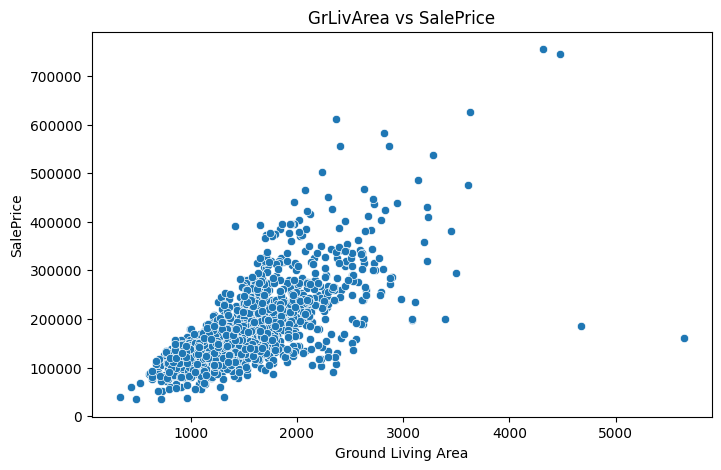

In [140]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train_data, x="GrLivArea", y="SalePrice")

plt.title("GrLivArea vs SalePrice")
plt.xlabel("Ground Living Area")
plt.ylabel("SalePrice")

plt.show()

In [141]:
outliers = train_data[(train_data["GrLivArea"] > 4000) & (train_data["SalePrice"] < 300000)]
outliers[["Id", "GrLivArea", "SalePrice"]]

,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


These two houses have very large living area but unusually low prices, so I remove them to reduce their effect on regression modeling.

In [142]:
train_data = train_data.drop(outliers.index)

print("Train shape after removing outliers:", train_data.shape)

Train shape after removing outliers: (1458, 81)


## 2.3 SalePrice Log Transformation

I visualize the original `SalePrice` distribution, then apply `np.log1p` because the target variable is right-skewed.

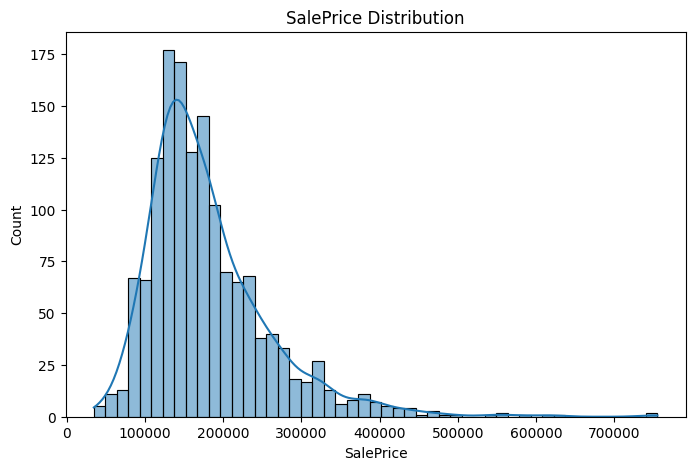

In [143]:
plt.figure(figsize=(8, 5))
sns.histplot(train_data["SalePrice"], kde=True)

plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")

plt.show()

In [144]:
train_data["SalePrice_log"] = np.log1p(train_data["SalePrice"])

train_data[["SalePrice", "SalePrice_log"]].head()

,SalePrice,SalePrice_log
0,208500,12.247699
1,181500,12.109016
2,223500,12.317171
3,140000,11.849405
4,250000,12.429220


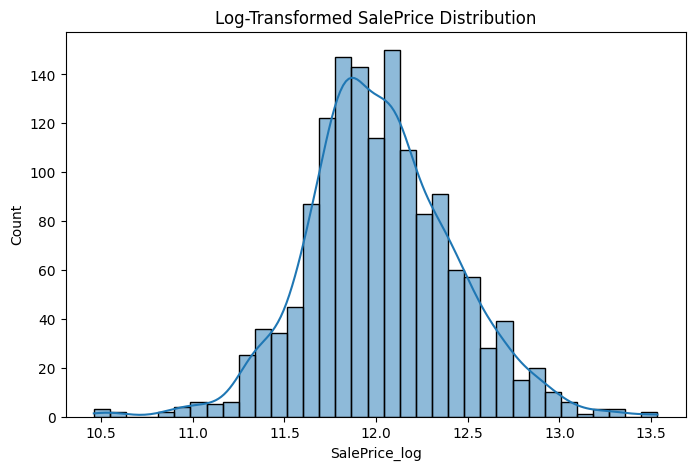

In [145]:
plt.figure(figsize=(8, 5))
sns.histplot(train_data["SalePrice_log"], kde=True)

plt.title("Log-Transformed SalePrice Distribution")
plt.xlabel("SalePrice_log")
plt.ylabel("Count")

plt.show()

In [146]:
print("Original SalePrice skewness:", train_data["SalePrice"].skew())
print("Log SalePrice skewness:", train_data["SalePrice_log"].skew())

Original SalePrice skewness: 1.8812964895244009
Log SalePrice skewness: 0.12157976050304879


# 3. Exploratory Data Analysis

In this section, I explore the data using correlations and visualizations to understand important relationships with `SalePrice`.

## 3.1 Correlation Analysis

I calculate the correlation between numerical features and `SalePrice`, then select the top 5 most related features.

In [147]:
numeric_data = train_data.select_dtypes(include=["int64", "float64"])

correlation = numeric_data.corr()

top_5_features = (
    correlation["SalePrice"]
    .drop(["SalePrice", "SalePrice_log", "Id"], errors="ignore")
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

top_5_features

,SalePrice
OverallQual,0.795774
GrLivArea,0.734968
TotalBsmtSF,0.651153
GarageCars,0.641047
1stFlrSF,0.631530


The strongest numerical relationship with `SalePrice` is `OverallQual`, followed by `GrLivArea`.  
This suggests that house quality and living area are very important factors in house pricing.

The heatmap below shows the correlations between the top 5 numerical features and `SalePrice`.

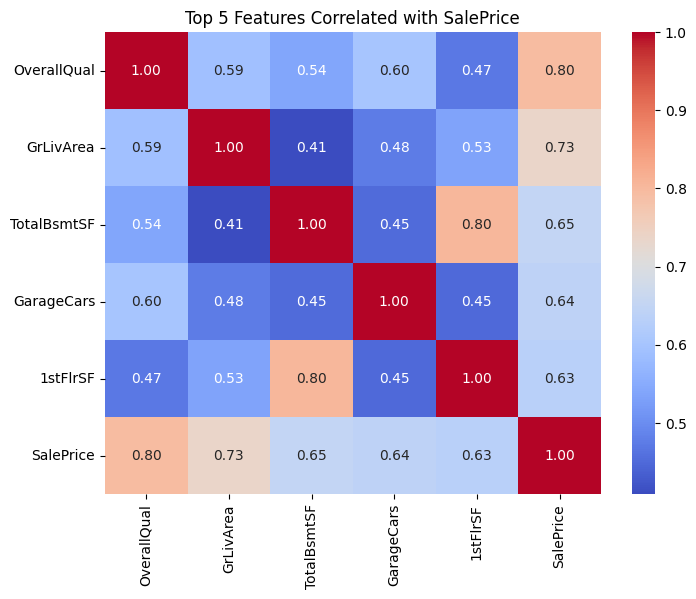

In [148]:
top_5_columns = top_5_features.index.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(
    train_data[top_5_columns + ["SalePrice"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top 5 Features Correlated with SalePrice")
plt.show()

## 3.2 Visual Exploration

I visualize the relationship between `GrLivArea` and `SalePrice`, using `OverallQual` as the color.

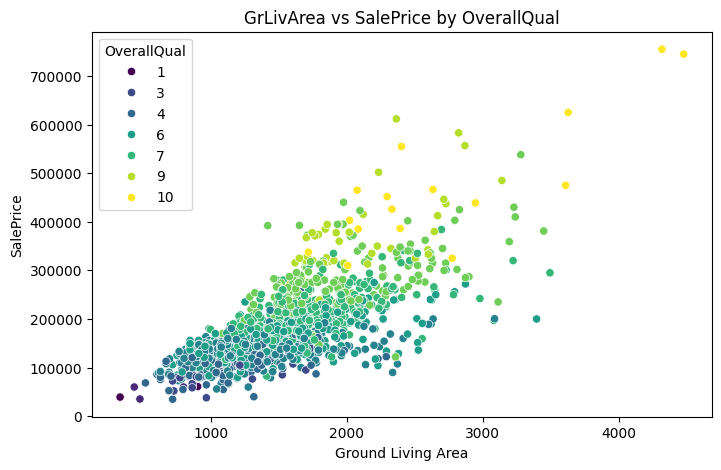

In [149]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_data,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    palette="viridis"
)

plt.title("GrLivArea vs SalePrice by OverallQual")
plt.xlabel("Ground Living Area")
plt.ylabel("SalePrice")

plt.show()

The plot shows a positive relationship between `GrLivArea` and `SalePrice`.  
Larger houses usually have higher prices, and houses with higher `OverallQual` tend to be more expensive.

## 3.3 Average SalePrice by Neighborhood

I calculate and visualize the average `SalePrice` for each neighborhood using Plotly Express.

In [150]:
neighborhood_prices = (
    train_data.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

neighborhood_prices.head()

,Neighborhood,SalePrice
0,NoRidge,335295.317073
1,NridgHt,316270.623377
2,StoneBr,310499.000000
3,Timber,242247.447368
4,Veenker,238772.727273


In [151]:
fig = px.bar(
    neighborhood_prices,
    x="SalePrice",
    y="Neighborhood",
    orientation="h",
    title="Average SalePrice by Neighborhood",
    labels={"SalePrice": "Average SalePrice", "Neighborhood": "Neighborhood"}
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    height=700
)

fig.show()

The chart shows that average house prices vary across neighborhoods.  
Neighborhoods such as `NoRidge`, `NridgHt`, and `StoneBr` have the highest average `SalePrice`.

# 4. Feature Engineering

In this section, I create new features and encode categorical variables to prepare the data for modeling.

## 4.1 Create TotalSF

I create a new feature called `TotalSF` by adding basement, first floor, and second floor areas.

In [152]:
train_data["TotalSF"] = (
    train_data["TotalBsmtSF"] +
    train_data["1stFlrSF"] +
    train_data["2ndFlrSF"]
)

test_data["TotalSF"] = (
    test_data["TotalBsmtSF"] +
    test_data["1stFlrSF"] +
    test_data["2ndFlrSF"]
)

train_data[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


`TotalSF` combines the main area-related features into one feature that represents the total house size.

## 4.2 Ordinal Encoding

Some categorical features have a clear order, such as quality levels.  
I convert these ordered categories into numerical values.

In [153]:
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

quality_columns = [
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond",
    "HeatingQC", "KitchenQual",
    "FireplaceQu",
    "GarageQual", "GarageCond",
    "PoolQC"
]

for col in quality_columns:
    train_data[col] = train_data[col].map(quality_map)
    test_data[col] = test_data[col].map(quality_map)

In [154]:
train_data[quality_columns].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,PoolQC
0,4,3,4,3,5,4,0,3,3,0
1,3,3,4,3,5,3,3,3,3,0
2,4,3,4,3,5,4,3,3,3,0
3,3,3,3,4,4,4,4,3,3,0
4,4,3,4,3,5,4,3,3,3,0


The quality columns are now converted from ordered text values into numerical values.

## 4.3 One-Hot Encoding

For nominal categorical features, I use One-Hot Encoding because these features do not have a natural order.

In [155]:
train_ids = train_data["Id"]
test_ids = test_data["Id"]

y_train = train_data["SalePrice_log"]

train_features = train_data.drop(["Id", "SalePrice", "SalePrice_log"], axis=1)
test_features = test_data.drop(["Id"], axis=1)

In [156]:
combined_data = pd.concat([train_features, test_features], axis=0)

print("Combined data shape before encoding:", combined_data.shape)

Combined data shape before encoding: (2917, 80)


In [157]:
combined_encoded = pd.get_dummies(combined_data, dtype=int)

print("Combined data shape after encoding:", combined_encoded.shape)

Combined data shape after encoding: (2917, 262)


In [158]:
X_train = combined_encoded.iloc[:len(train_features), :]
X_test = combined_encoded.iloc[len(train_features):, :]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1458, 262)
X_test shape: (1459, 262)
y_train shape: (1458,)


After encoding, all features are numerical and ready for regression modeling.

## 4.4 Reusable Preprocessing Function

I create a reusable function that applies the main preprocessing steps to raw training and testing data.

In [159]:
def preprocess_data(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Remove clear outliers from training data
    outliers = train_df[(train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 300000)]
    train_df = train_df.drop(outliers.index)

    # Save IDs
    train_ids = train_df["Id"]
    test_ids = test_df["Id"]

    # Log transform target
    y_train = np.log1p(train_df["SalePrice"])

    # Missing values where NaN means the feature does not exist
    special_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]
    garage_cat_cols = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]
    bsmt_cat_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
    none_cols = special_cols + garage_cat_cols + bsmt_cat_cols + ["MasVnrType"]

    for col in none_cols:
        if col in train_df.columns:
            train_df[col] = train_df[col].fillna("None")
            test_df[col] = test_df[col].fillna("None")

    garage_num_cols = ["GarageYrBlt", "GarageArea", "GarageCars"]
    bsmt_num_cols = ["BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath"]
    zero_cols = garage_num_cols + bsmt_num_cols + ["MasVnrArea"]

    for col in zero_cols:
        if col in train_df.columns:
            train_df[col] = train_df[col].fillna(0)
            test_df[col] = test_df[col].fillna(0)

    # LotFrontage: fill using train median
    train_lot_median = train_df["LotFrontage"].median()
    train_df["LotFrontage"] = train_df["LotFrontage"].fillna(train_lot_median)
    test_df["LotFrontage"] = test_df["LotFrontage"].fillna(train_lot_median)

    # Fill remaining missing values using train statistics
    for col in test_df.columns:
        if train_df[col].dtype == "object":
            fill_value = train_df[col].mode()[0]
        else:
            fill_value = train_df[col].median()

        train_df[col] = train_df[col].fillna(fill_value)
        test_df[col] = test_df[col].fillna(fill_value)

    # Create TotalSF
    train_df["TotalSF"] = train_df["TotalBsmtSF"] + train_df["1stFlrSF"] + train_df["2ndFlrSF"]
    test_df["TotalSF"] = test_df["TotalBsmtSF"] + test_df["1stFlrSF"] + test_df["2ndFlrSF"]

    # Ordinal Encoding
    quality_map = {
        "None": 0,
        "Po": 1,
        "Fa": 2,
        "TA": 3,
        "Gd": 4,
        "Ex": 5
    }

    quality_columns = [
        "ExterQual", "ExterCond",
        "BsmtQual", "BsmtCond",
        "HeatingQC", "KitchenQual",
        "FireplaceQu",
        "GarageQual", "GarageCond",
        "PoolQC"
    ]

    for col in quality_columns:
        if col in train_df.columns:
            train_df[col] = train_df[col].map(quality_map)
            test_df[col] = test_df[col].map(quality_map)

    # Separate features
    train_features = train_df.drop(["Id", "SalePrice"], axis=1)
    test_features = test_df.drop(["Id"], axis=1)

    # One-Hot Encoding
    combined_data = pd.concat([train_features, test_features], axis=0)
    combined_encoded = pd.get_dummies(combined_data, dtype=int)

    X_train = combined_encoded.iloc[:len(train_features), :]
    X_test = combined_encoded.iloc[len(train_features):, :]

    return X_train, X_test, y_train, train_ids, test_ids

I test the function using the original raw files to make sure the preprocessing steps work from start to finish.

In [160]:
raw_train = pd.read_csv("data/train.csv")
raw_test = pd.read_csv("data/test.csv")

X_train_func, X_test_func, y_func, train_ids_func, test_ids_func = preprocess_data(raw_train, raw_test)

print("X_train shape:", X_train_func.shape)
print("X_test shape:", X_test_func.shape)
print("y shape:", y_func.shape)

print("Missing values in X_train:", X_train_func.isnull().sum().sum())
print("Missing values in X_test:", X_test_func.isnull().sum().sum())
print("Missing values in y:", y_func.isnull().sum())

X_train shape: (1458, 262)
X_test shape: (1459, 262)
y shape: (1458,)
Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y: 0


# 5. Final Processed Data

I check the final processed datasets to make sure they are ready for regression modeling.

In [161]:
X_train_final = X_train_func.copy()
X_test_final = X_test_func.copy()
y_train_final = y_func.copy()

print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)
print("Final y_train shape:", y_train_final.shape)

print("\nMissing values in X_train:", X_train_final.isnull().sum().sum())
print("Missing values in X_test:", X_test_final.isnull().sum().sum())
print("Missing values in y_train:", y_train_final.isnull().sum())

Final X_train shape: (1458, 262)
Final X_test shape: (1459, 262)
Final y_train shape: (1458,)

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0


All features are now numerical, missing values are handled, outliers are removed, and the target variable is log-transformed.

In [162]:
os.makedirs("processed_data", exist_ok=True)

X_train_final.to_csv("processed_data/X_train_processed.csv", index=False)
X_test_final.to_csv("processed_data/X_test_processed.csv", index=False)
y_train_final.to_csv("processed_data/y_train_log.csv", index=False)

print("Processed files saved successfully.")

Processed files saved successfully.


## Final Summary

In this notebook, I loaded the House Prices dataset, handled missing values, removed clear outliers, applied log transformation to `SalePrice`, explored important relationships using EDA, created the `TotalSF` feature, and encoded categorical variables.

The final processed data is ready for regression modeling.